In [7]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import jax
import jax.numpy as jnp

import matplotlib.pylab as pylab
pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting

saveFigs = False

w:\Programs\anaconda3\envs\PyGhostID\Lib\site-packages\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


Supp Figure 1a: bifurcation diagram

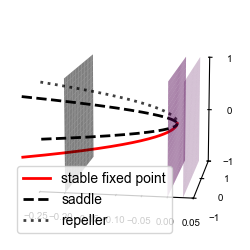

In [8]:
mu_values = [-0.2, 0, 0.03] # Saddle & Stable FP

fig = plt.figure(figsize=(7*inCm,7*inCm))
ax = fig.add_subplot(projection='3d')

mu_range = np.linspace(-0.3,0,200)

x_stable = -np.sqrt(-mu_range)
y_stable = -np.sqrt(-mu_range)

x_saddle1 = np.sqrt(-mu_range)
y_saddle1 = -np.sqrt(-mu_range)

x_saddle2 = -np.sqrt(-mu_range)
y_saddle2 = np.sqrt(-mu_range)

x_repeller = np.sqrt(-mu_range)
y_repeller = np.sqrt(-mu_range)

def add_vertical_plane(ax, mu_value, xlim=(-1,1), ylim=(-1,1),
                       color='k', alpha=0.5):
    """
    Draws a plane perpendicular to μ-axis (constant μ).
    """
    Xp, Yp = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 20),
        np.linspace(ylim[0], ylim[1], 20)
    )
    Zp = np.full_like(Xp, mu_value)  # plane at fixed μ (z is μ)
    ax.plot_surface(Zp, Xp, Yp, color=color, alpha=alpha, linewidth=0)

# Example μ-values (you can set your own):


add_vertical_plane(ax, mu_values[0], color='k', alpha=0.5)
add_vertical_plane(ax, mu_values[1], color='m', alpha=0.5)
add_vertical_plane(ax, mu_values[2], color='m', alpha=0.25)
# ---------------------------
# Curves
# ---------------------------

ax.plot3D(mu_range, x_stable,  y_stable, '-r', lw=2, label='stable fixed point')
ax.plot3D(mu_range, x_saddle1, y_saddle1, '--k', lw=2, label='saddle')
ax.plot3D(mu_range, x_saddle2, y_saddle2, '--k', lw=2)
ax.plot3D(mu_range, x_repeller, y_repeller, ':k', lw=2, alpha=0.75, label='repeller')

# ---------------------------
# Labels & axes
# ---------------------------

plt.legend()
ax.set_xlabel("$\\mu$")
ax.set_ylabel("$x_1$")
ax.set_zlabel("$x_2$")

ax.set_xlim(-0.25,0.05); ax.set_xticks([-0.25,-0.2,-0.15,-0.1,-0.05,0,0.05]); #ax.set_xticklabels(['','-0.2','','-0.1','','0.0',''])
ax.set_ylim(-1,1);     ax.set_yticks([-1,-0,1])
ax.set_zlim(-1,1);     ax.set_zticks([-1,0,1])

fun.noBackground(ax)   # keep your background removal

# ---------------------------
# 2) Turn commented lines into code
# ---------------------------

plt.subplots_adjust(
    top=0.965,
    bottom=0.0,
    left=0.0,
    right=0.835,
    hspace=0.185,
    wspace=0.185
)

ax.view_init(elev=12, azim=-81)

if saveFigs:    plt.savefig("SFig1a.svg")

In [4]:
print("Perform manual analyses for saddle model...")

# Define grid
xmin=-1;xmax=1
ymin=-1;ymax=1

Ng=150
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

# Eigenvalues on grid
print("Eigenvalue calculations...")

def eigValsOnGrid_system2(X_grid, Y_grid):

    lambda1 = np.zeros_like(X_grid)
    lambda2 = np.zeros_like(X_grid)

    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            x,y = [X_grid[i, j], Y_grid[i, j]]
            lambda1[i,j]= 2*x
            lambda2[i,j]= 2*y

    return [lambda1, lambda2]

lambdas = eigValsOnGrid_system2(Xg, Yg)

Qgrids = []
print("Q calculation ...")
for mu in mu_values:
    print("mu = ", mu)
    Q, coords = gid.qOnGrid(mod.snb_2dnf,[mu],coords=[x_range,y_range], jit=True)
    Qgrids.append(Q)

print("Done.")

Perform manual analyses for saddle model...
Eigenvalue calculations...
Q calculation ...
mu =  -0.2
mu =  0
mu =  0.03
Done.


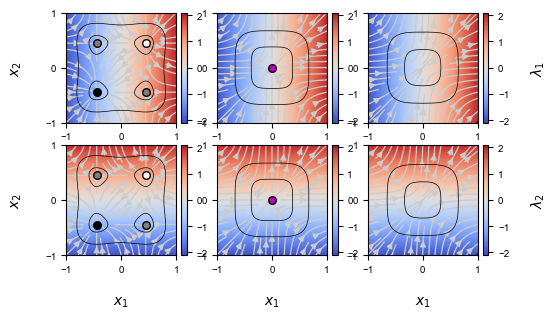

In [9]:
plt.figure(figsize=(14*inCm,8*inCm))

for i in range (3):

    mu = mu_values[i]

    dt = 0.01
    timesteps = np.linspace(0,100,int(100/dt))
    sol = solve_ivp(mod.snb_2dnf, (0, 100), [-4,-4],
                        t_eval=timesteps, args=([mu],),method='RK45')


    def flow_model(t,z): 
            return mod.snb_2dnf(t,z,[mu_values[i]]) 
    U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 
    

    vmin=float(np.min(np.asarray(lambdas)))*1.05
    vmax=float(np.max(np.asarray(lambdas)))*1.05

    for ii in range(2):
    
        plt.subplot(2,3,1+i + ii*3 )
        ax = plt.gca()
        ax.streamplot(Xg,Yg,U,V,density=0.65,color=[0.8,0.8,0.8,1],arrowsize=0.9,linewidth=0.9) 

        im = ax.imshow(lambdas[ii], extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='coolwarm', vmin=vmin, vmax=vmax) 
        
        # Overlay contour for Q < 0.01
        levels = [1e-2,1e-1,1]
        cs = ax.contour(
            x_range,             # x coordinates
            y_range,             # y coordinates
            Qgrids[i].T,         # match imshow orientation
            levels=levels,      # single contour at 0.01
            colors='k',       # choose any color
            linewidths=0.5
        )
        # ax.clabel(cs, fontsize=10)
        if mu < 0:
            ax.scatter(
                [-np.sqrt(-mu)], [-np.sqrt(-mu)],
                s=30,          # dot size
                c='black',
                edgecolors='black',
                marker='o',
                alpha=1,
                zorder=5
            )
            ax.scatter(
                [np.sqrt(-mu)], [np.sqrt(-mu)],
                s=30,          # dot size
                c='white',
                edgecolors='black',
                marker='o',
                alpha=1,
                zorder=5
            )
            ax.scatter(
                [-np.sqrt(-mu)], [np.sqrt(-mu)],
                s=30,          # dot size
                c='grey',
                edgecolors='black',
                marker='o',
                alpha=1,
                zorder=5
            )
            ax.scatter(
                [np.sqrt(-mu)], [-np.sqrt(-mu)],
                s=30,          # dot size
                c='grey',
                edgecolors='black',
                marker='o',
                alpha=1,
                zorder=5
            )
        
        if mu == 0:
            ax.scatter(
                [np.sqrt(-mu)], [0],
                s=30,          # dot size
                c='m',
                edgecolors='black',
                marker='o',
                alpha=1,
                zorder=5
            )
        
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax, label = f"$\\lambda_{ii+1}$")
        if ii == 1:
            ax.set_xlabel('$x_1$'); 
        if i == 0:
            ax.set_ylabel('$x_2$')
        ax.set_xlim(xmin,xmax);ax.set_ylim(ymin,ymax)
        ax.set_xticks([-1,-0,1]); ax.set_yticks([-1,-0,1])

if saveFigs: plt.savefig("SFig1b.svg")